# Trackmania Monte Carlo Simulator — Exploration


In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

from tmonacodel import TournamentConfig, run_monte_carlo, REAL_PLAYERS
from tmonacodel.racer import make_racer_pool

sns.set_theme(style='whitegrid')

## Run simulation


In [2]:
config = TournamentConfig(n_simulations=10_000, random_seed=None)
results = run_monte_carlo(config, player_data=REAL_PLAYERS)
print(f'Simulated {config.n_simulations} seasons with {config.n_players} players')
print(f'Real players: {len(REAL_PLAYERS)}, Generic fill: {config.n_players - len(REAL_PLAYERS)}')

Simulated 10000 seasons with 128 players
Real players: 98, Generic fill: 30


## Summary table


In [3]:
df = results.summary_dataframe()
df[['name', 'country', 'mean_rank', 'median_rank', 'prob_top_N']].head(20)

,name,country,mean_rank,median_rank,prob_top_N
0,Nayko,France,63.6414,63.0,0.1318
1,Hyll,Czechia,63.7420,63.0,0.1295
2,pusztitopako,Hungary,63.7599,64.0,0.1294
3,Charles,Colombia,63.8030,64.0,0.1282
4,noiszia,Argentina,63.8200,63.0,0.1263
5,josh1248,United Kingdom,63.8641,64.0,0.1294
6,Epos,United Kingdom,63.8719,63.0,0.1285
7,Azion,France,63.8774,63.0,0.1273
8,Jan,Germany,63.8867,63.0,0.1257
9,Generic_01,Croatia,63.9228,64.0,0.1254


## EWC Qualifying Score (PQ)

In [4]:
pq = results.ewc_qualifying_score(top_n=8)
print(f"PQ (guaranteed top-8 qualifying score): {pq} points")

PQ (guaranteed top-8 qualifying score): 1664 points


## Qualification likelihood by score

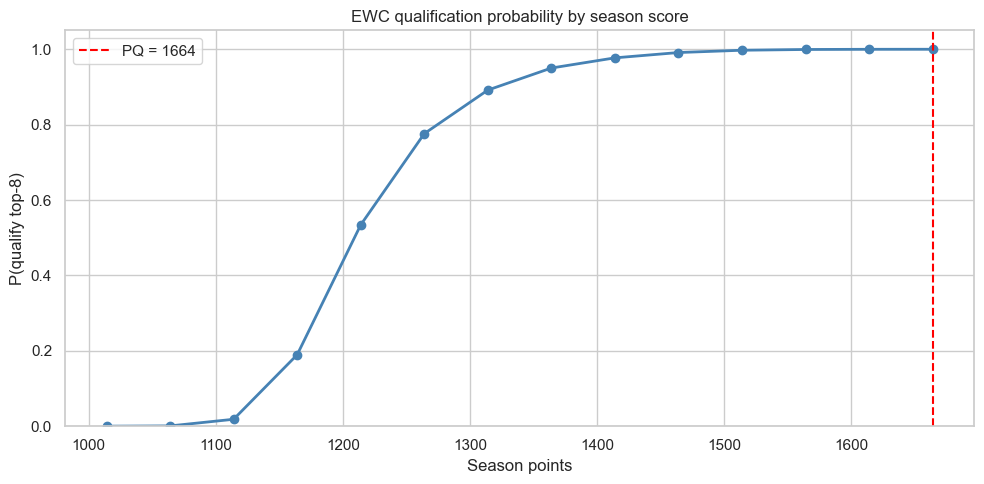

In [11]:
curve = results.ewc_qualification_curve(top_n=8, step=50)
curve_plot = curve.sort_values("score")
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(curve_plot["score"], curve_plot["prob_qualify"], marker="o", linewidth=2, color="steelblue")
ax.axvline(pq, color="red", linestyle="--", label=f"PQ = {pq}")
ax.set_xlabel("Season points")
ax.set_ylabel("P(qualify top-8)")
ax.set_title("EWC qualification probability by season score")
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.show()

## Minimum score to top national table

In [13]:
nation_tops = results.nation_topping_scores()
nation_tops

,country,player_count,min_score_to_top_nation
0,Turkey,4,4300
1,United States,4,3900
2,Germany,14,3900
3,Slovenia,2,3900
4,Canada,2,3900
5,France,35,3800
6,Belgium,4,3700
7,Israel,2,3684
8,New Zealand,4,3600
9,Poland,10,3530


## Average points by finishing rank

In [12]:
rank_df = results.rank_points_profile()
print(rank_df[0:8].to_string(index=False))

 rank  mean_points  p10_points  p90_points
    1       2064.7        1684        2516
    2       1762.3        1496        2078
    3       1600.0        1372        1824
    4       1481.8        1284        1698
    5       1389.6        1230        1576
    6       1319.2        1198        1476
    7       1265.6        1170        1396
    8       1223.7        1148        1320


## Plot: Points distribution for one player


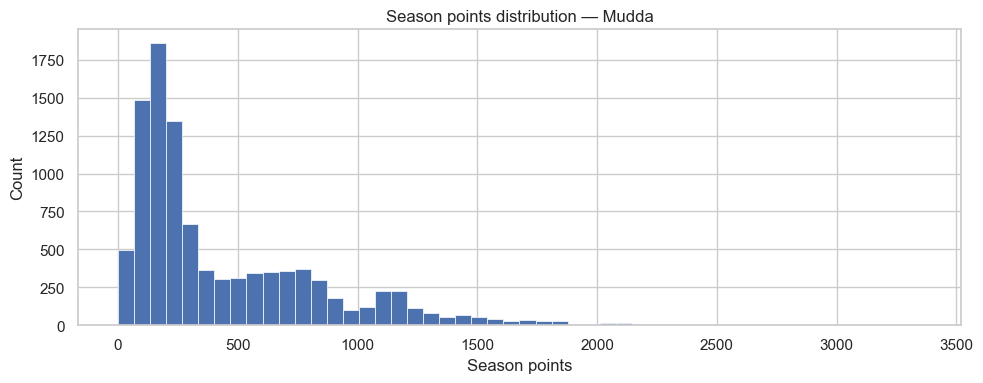

In [10]:
racer_id = 0
dist = results.points_distribution(racer_id)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(dist, bins=50, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Season points')
ax.set_ylabel('Count')
ax.set_title(f'Season points distribution — {results.racers[racer_id].name}')
plt.tight_layout()
plt.show()